In [8]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(patchwork)
library(cowplot)
library(Matrix)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(msigdbr)
library(tidyverse)
library(ggpubr)
library(rstatix)
library(ggprism)
library(reshape2)
library(Seurat)
library(ggplot2)
library(cowplot)
library(tidyverse)
library(dplyr)
library(Seurat)
library(ggplot2)
library(patchwork)
library(ggsci)
library(circlize)
library(RColorBrewer)
library(ComplexHeatmap)
library(scCustomize)
library(ggplot2)
library(ggforce)
library(dplyr)
library(ggrepel)
library(patchwork)
library(ggpubr)
library(export)
library(org.Mm.eg.db)#
library("clusterProfiler")
library(biomaRt)
library(tidyverse)
library(limma)
library(IOBR)
library(fgsea)
library(Seurat)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(DESeq2)
library("FactoMineR")
library(ggplot2)
library(vegan)
library(ape)
library(phyloseq)
library(ggalt)
library(microeco)
#library(jsd)
library("factoextra")
library(Seurat)
library(stringr)
library(ggplot2)
library(pheatmap)
library(dplyr)
library("spatstat.geom")
library(Seurat)
library(Rcpp)
library(harmony)
library(stringr)
library(dplyr)
library(patchwork)
library(ggplot2)
library(ggpubr)
library(reshape2)
library(scales)
library(ggsignif)
library(corrplot)
library(edgeR)
library(ggplot2)
library(FactoMineR)
library(factoextra)  
library(corrplot)   
library(pheatmap)
library(tidyverse)
library(clusterProfiler)
library(org.Hs.eg.db)  
library(GSEABase)    
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(cowplot)
library(monocle)
library(tidyverse)
library(reshape2)
library(ggplot2)
library(ggpubr)
library(GO.db)
library(org.Hs.eg.db)
library(clusterProfiler)
library(enrichplot)
library(ggplot2)
library(ggnewscale)
library(org.Mm.eg.db)
library(dplyr)
library(stringr)
library(ComplexUpset)
options(warn=-1)####忽略警告

In [9]:
gpl <- getGEO("GPL21827", destdir = ".")
# 提取注释表格
annotation <- Table(gpl)
# 查看列名
head(annotation)

Using locally cached version of GPL21827 found here:
./GPL21827.soft.gz 



,ID,TRANSCRIPT_TYPE,BUILD,SEQUENCE,SPOT_ID
,<chr>,<chr>,<chr>,<chr>,<chr>
1,ASHGV40000001,noncoding,HG19,AGTGATGATGATTAAAGGTGGTGGCTGTGGCCTTGAAAACAGTCATGTGAAAACTCATCA,
2,ASHGV40000002,noncoding,HG19,ATTTCTGTAAATGGTGCAGTCAGCCTCAGTTTCCAAAGCCGGAAAAGGATCCTCTAGTAG,
3,ASHGV40000003,noncoding,HG19,GCACACGAAGCCTGTTAATATGATGAATTACACTGATTCAGTTTCAAATGTCCAACCAAG,
4,ASHGV40000004,noncoding,HG19,CCCTCTTCGAATCCCGCCTGCGCAACTCCCACCCGCCTTCTCCGAGCTGATGCCAAGGCC,
5,ASHGV40000005,noncoding,HG19,AGGGTTTCACCTTGGCACACTCCTGACAGTCTGACTCCATCTTCTCAGCCTTCCCCCGCT,
6,ASHGV40000006,protein_coding,HG19,TGACATTTCTGAGTCAGCCAAGGACTTTATTTGCCACTTGCTTGAGAAGGATCCGAACGA,


In [10]:
m <- read.csv("GSE101727_series_matrix.csv")

In [11]:
library(idmap3)

idmap3 v 0.1.0  welcome to use idmap3!
If you use idmap3 in published research, please acknowledgements:
We thank Dr.Jianming Zeng(University of Macau), and all the members of his bioinformatics team, biotrainee, for generously sharing their experience and codes.



In [12]:
library(idmap3)
ids=idmap3::get_pipe_IDs('GPL21827')
head(ids)

,probe_id,symbol
,<chr>,<chr>
1,ASHGV40003982,DDX11L1
2,ASHGV40056224,DDX11L1
3,ASHGV40056225,DDX11L1
4,ASHGV40057492,WASH7P
5,ASHGV40001398,WASH7P
6,ASHGV40003684,WASH7P


In [13]:
ids[which(ids$symbol=="ENPP7"),]

,probe_id,symbol
,<chr>,<chr>
46812,ASHGV40020957,ENPP7
46813,ASHGV40022314,ENPP7


In [14]:
cs <- intersect(ids$probe_id,m$ID_REF)

In [15]:
length(cs)

[1] 41542

In [16]:
m1 <- subset(m,subset = ID_REF%in%cs)

In [17]:
m1$symbol <- "NA"
for(i in unique(m1$ID_REF)){
    symbol <- ids[which(ids$probe_id==i),][1,]$symbol
    m1[which(m1$ID_REF==i),]$symbol <- symbol
}

In [18]:
length(unique(m1$symbol))

[1] 27867

In [19]:
mer2 <- remove_duplicate_genes(m1, column_of_symbol = "symbol", method = "mean")
mer3 <- mer2[,-1]

In [20]:
colnames(mer3)

[1] "GSM2714108" "GSM2714109" "GSM2714110" "GSM2714111" "GSM2714112"
 [6] "GSM2714113" "GSM2714114" "GSM2714115" "GSM2714116" "GSM2714117"
[11] "GSM2714118" "GSM2714119" "GSM2714120" "GSM2714121" "GSM2714122"
[16] "GSM2714123" "GSM2714124" "GSM2714125" "GSM2714126" "GSM2714127"

In [21]:
sp <- CreateSeuratObject(mer3,min.cells = 0)
sp

An object of class Seurat 
27867 features across 20 samples within 1 assay 
Active assay: RNA (27867 features, 0 variable features)
 1 layer present: counts

In [22]:
sp@meta.data$group <- c("Control","Control","Control","Control","Control",
                        "Control","Control","Control","Control","Control",
                        "POAG","POAG","POAG","POAG","POAG",
                        "POAG","POAG","POAG","POAG","POAG")
sp@meta.data

,orig.ident,nCount_RNA,nFeature_RNA,group
,<fct>,<dbl>,<int>,<chr>
GSM2714108,SeuratProject,121982.9,27867,Control
GSM2714109,SeuratProject,121880.0,27867,Control
GSM2714110,SeuratProject,121530.9,27867,Control
GSM2714111,SeuratProject,121643.5,27867,Control
GSM2714112,SeuratProject,121604.4,27867,Control
GSM2714113,SeuratProject,121617.6,27867,Control
GSM2714114,SeuratProject,121805.1,27867,Control
GSM2714115,SeuratProject,121144.9,27867,Control
GSM2714116,SeuratProject,121986.9,27867,Control


In [23]:
Idents(sp) <- as.factor(sp@meta.data$group)

In [24]:
sp@assays$RNA$data <- sp@assays$RNA$counts

In [25]:
exp <- mer3
exp1 <- exp

In [26]:
res.pca <-PCA(exp1, graph = FALSE)
eig.val <- get_eigenvalue(res.pca)
var <- get_pca_var(res.pca)
df1 <- merge(var$coord,sp@meta.data,all = TRUE,by = 0)
rownames(df1) <- df1$Row.names

In [27]:
unique(sp@meta.data$group)
sp@meta.data$group <- factor(sp@meta.data$group,levels = c('Control','POAG'))

[1] "Control" "POAG"

[1] "PCA1 (80.2%)"
[1] "PCA2 (7.26%)"


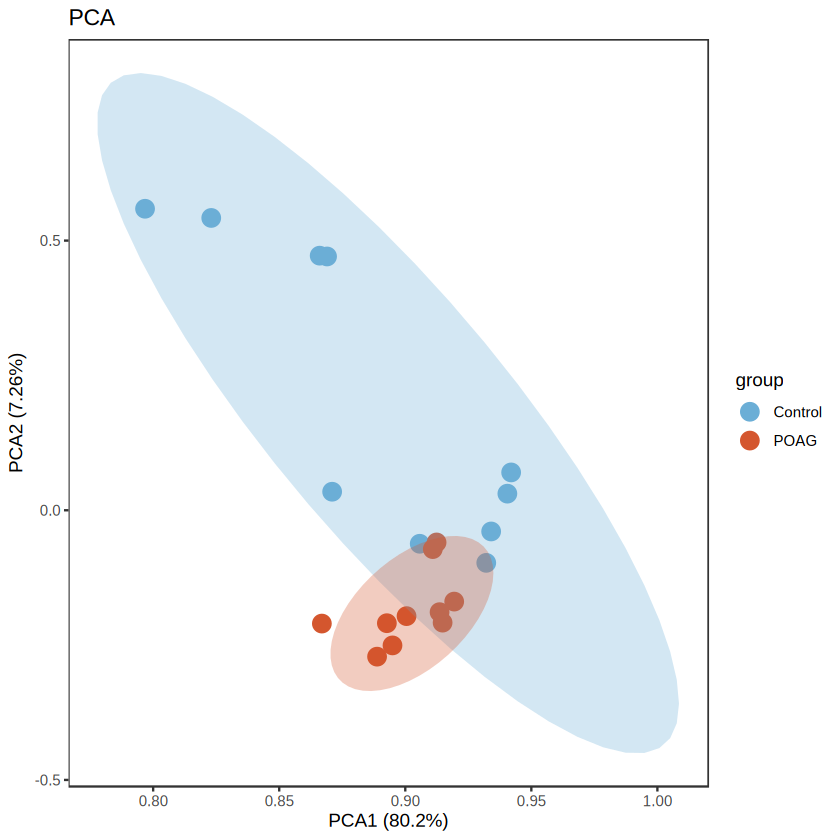

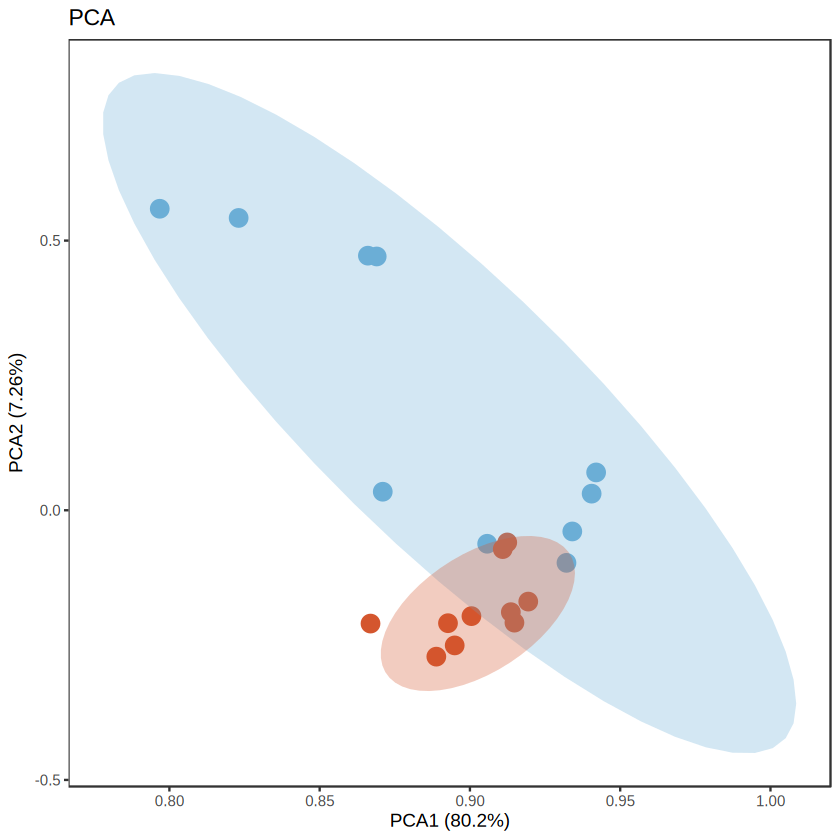

In [28]:
res.pca <-PCA(exp1, graph = FALSE)
eig.val <- get_eigenvalue(res.pca)
var <- get_pca_var(res.pca)
df1 <- merge(var$coord,sp@meta.data,all = TRUE,by = 0)
rownames(df1) <- df1$Row.names
order <- c('Control','POAG')
df1$group <- factor(df1$group,levels = order)
cell_type_cols <- c('Control'= '#6BAED6','POAG'='#D4562E')
cols1 <- c('Control'= '#6BAED6','POAG'='#D4562E')
pca1 = round(eig.val[1, 2], 2)
pca2 = round(eig.val[2, 2], 2)
xlab = paste0("PCA1 (",pca1,"%)")
ylab = paste0("PCA2 (",pca2,"%)")
print(xlab)
print(ylab)
p<-ggplot(data = df1, aes(Dim.1,Dim.2))+
geom_point(size=4.5,aes(color=group))+ 
scale_color_manual(values = cell_type_cols)+
  theme_bw()+theme(panel.grid = element_blank())+
stat_ellipse(data = df1,geom="polygon",level = 0.9,alpha = 0.3,linetype=1,aes(fill=group))+
scale_fill_manual(values = cell_type_cols)+
guides(fill=F)+##隐藏图例
  labs(x=xlab,y=ylab,title= "PCA")#+coord_cartesian(xlim = c(0.96, 0.99), ylim = c(-0.16, 0.16))
p1 <- p+theme(legend.position = "none")
p
p1

In [32]:
path1 <-getwd()

In [33]:
dat <- exp

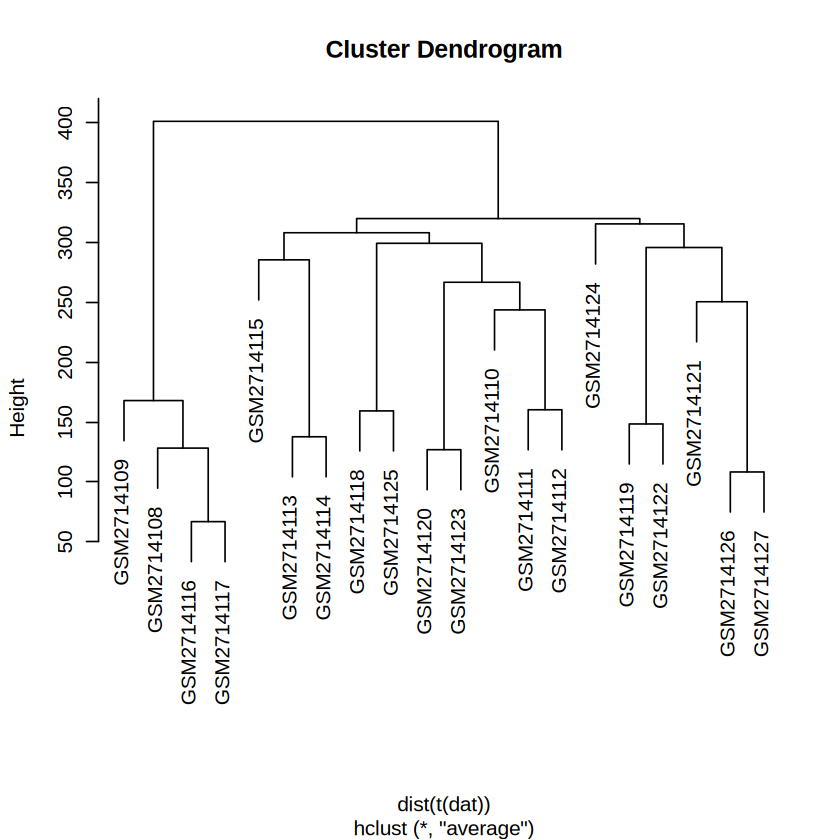

In [34]:
# 绘制层次聚类树
path2 <- paste0(path1,"01PCA_CorTest/")

if (!dir.exists(path2)) {
  dir.create(path2, recursive = TRUE)
}
setwd(path2)
sampleTree <- hclust(dist(t(dat)), method = "average")  # dist生成一个距离矩阵，计算的是行与行之间的距离，需要的是样本与样本间的距离，因此dat矩阵需要转置t(dat)
plot(sampleTree)   # 参数labels标签默认是NULL，表示变量原有名称，labels=F 则表示不显示标签
temp <- as.data.frame(cutree(sampleTree,k = 2)) 

In [28]:
sp@meta.data$group <- as.factor(sp@meta.data$group)
group_list <- as.factor(sp@meta.data$group)

In [29]:
dat <- as.data.frame(t(dat))   # 转置dat矩阵
dat_pca <- PCA(dat, graph = FALSE)
class(dat_pca)

[1] "PCA"  "list"

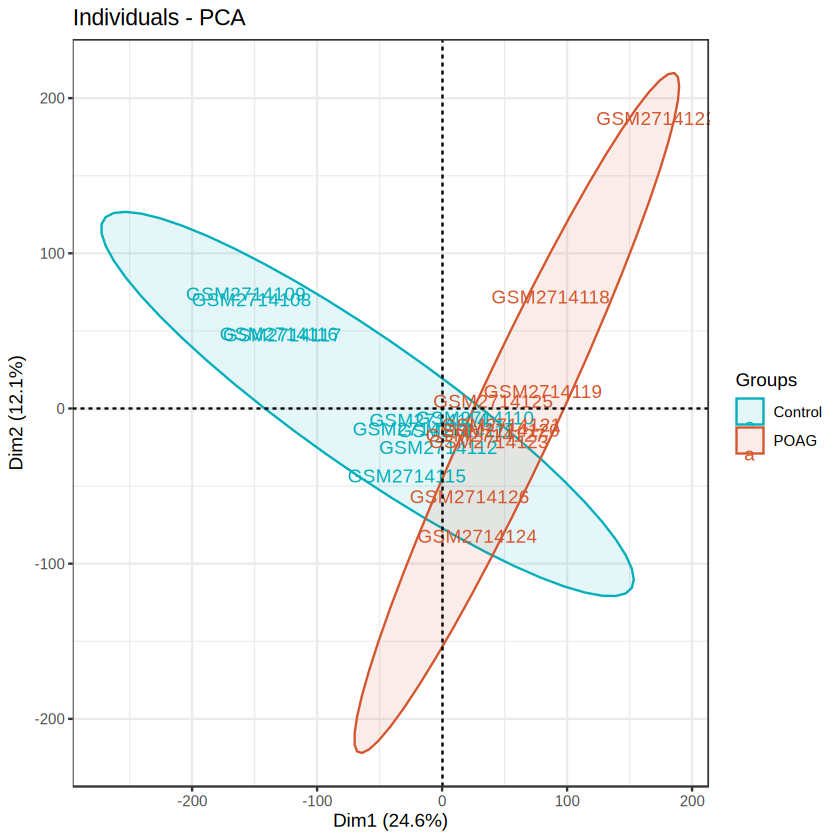

In [30]:
# 绘制主成分PCA图
p <- fviz_pca_ind(dat_pca,
                 geom.ind = "text",  # 画点代表样本的话用“point"
                 col.ind = group_list,
                 palett = c("#00AFBB","#D4562E","#FFC400"),  # 不同颜色表示不同分组
                 addEllipses = T,   # 是否加圈
                 legend.title = "Groups") + theme_bw()
p

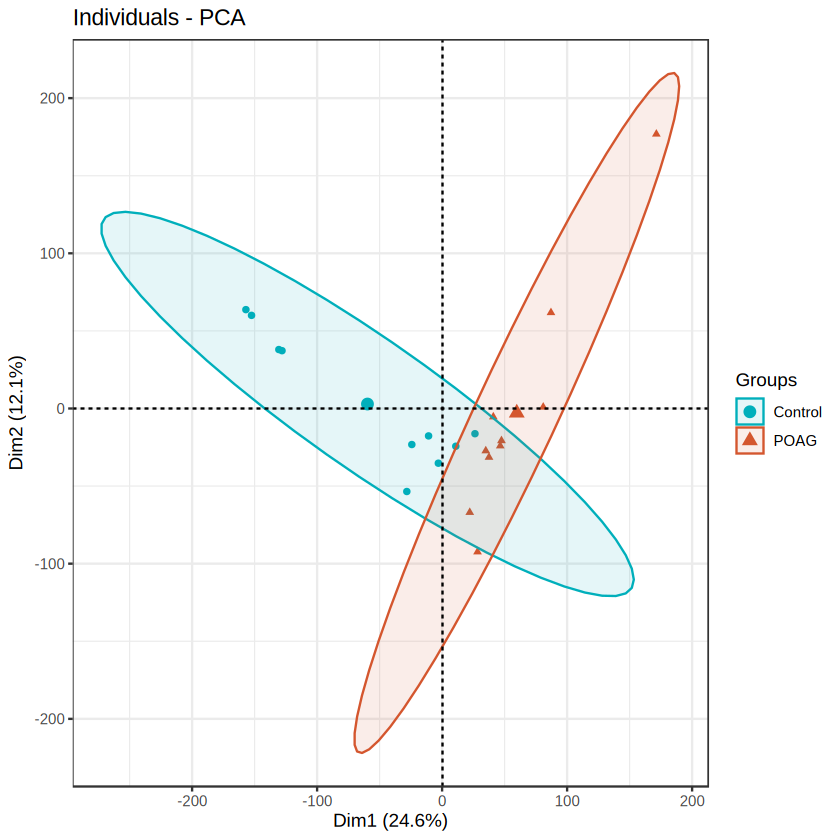

In [31]:
# 绘制主成分PCA图
p <- fviz_pca_ind(dat_pca,
                 geom.ind = "point",  # 画点代表样本的话用“point"
                 col.ind = group_list,
                 palett = c("#00AFBB","#D4562E","#FFC400"),  # 不同颜色表示不同分组
                 addEllipses = T,   # 是否加圈
                 legend.title = "Groups") + theme_bw()
p

In [35]:
m <- as.data.frame(scale(t(mer3)))
m$group <- sp@meta.data$group

In [32]:
col<-c("Control"="#6BAED6","POAG"="#f16c23")

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


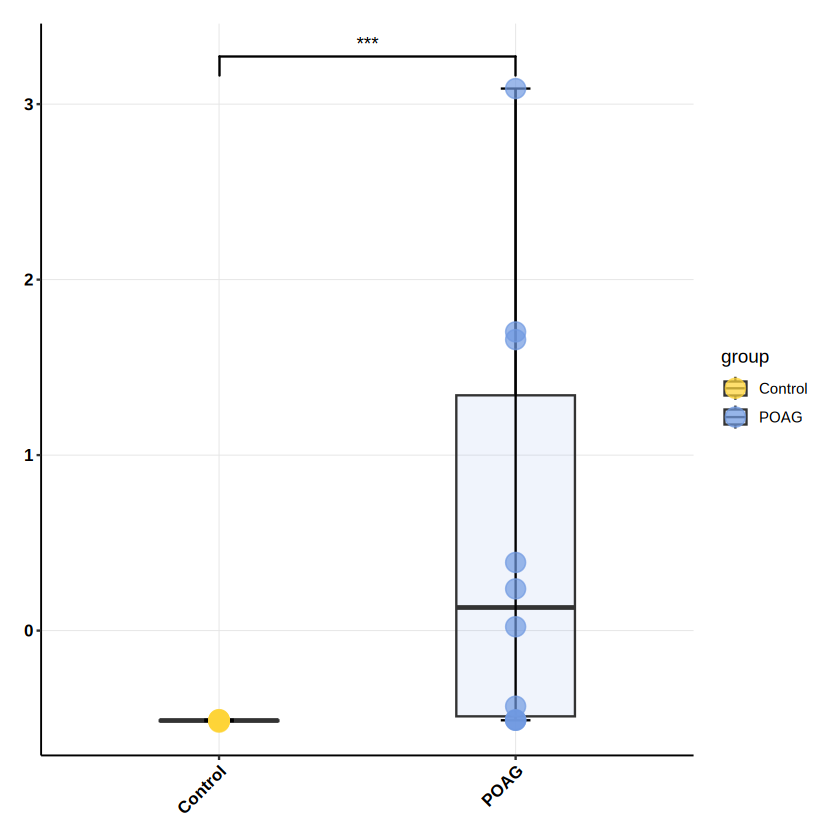

In [87]:
i="GLB1"
ggplot(m,aes(x=group,y=m[[i]],fill=group))+geom_boxplot(position=position_dodge(width=0.2), width=0.4,alpha=0.1) +
stat_boxplot(geom="errorbar", position=position_dodge(width=0.2), width=0.1)+geom_point(aes(fill=group, group=group, color=group), pch=21,size=5, position=position_dodge(0.4)) +
geom_signif(comparisons = list(c('Control','POAG')),map_signif_level = T,test = "wilcox.test",step_increase = 0.1)+
scale_fill_manual(values = col) +scale_color_manual(values = col)+
scale_fill_simpsons(alpha=0.7)+scale_color_simpsons(alpha=0.7)+labs(x=NULL, y=NULL)+
theme(plot.margin=unit(c(0.5, 0.5, 0.5, 0.5), units="cm"),  # 调整图形边距
axis.line=element_line(color="black", size=0.4), # 自定义坐标轴线
panel.grid.minor=element_blank(),  # 删除次要网格线
panel.grid.major=element_line(size=0.2, color="#e5e5e5"), # 自定义主要网格线
panel.background=element_blank(),  # 删除面板背景
axis.text.y=element_text(color="black", size=10, face="bold"), # 自定义y轴上的文本
axis.text.x=element_text(color="black", size=10, hjust=1, face="bold", angle=45), # 自定义x轴上的文本
axis.line.x.top=element_line(color="black"),  # 自定义顶部x轴线
c, # 删除顶部x轴上的文本
axis.ticks.y.right=element_blank(),  # 删除右侧y轴刻度
axis.text.y.right=element_blank(),  # 删除右侧y轴文本
axis.ticks.x.top=element_blank(), # 删除顶部x轴刻度
panel.spacing.x=unit(0, "cm"), # 删除x轴间距
panel.spacing=unit(0, "lines")
)


In [88]:
gs <- c("SPTLC1","UGT8","UGCG","ASAH1","SPHK2","ACER1","ACER2","GLB1","CERS4")

In [43]:
col<-c("Control"="#337AB7","POAG"="#F0AD4E")

In [60]:
head(genesets)

$`reactome glycosphingolipid metabolism`
 [1] "ARSA"     "ARSB"     "ARSD"     "ARSF"     "ARSG"     "ARSH"    
 [7] "ARSI"     "ARSJ"     "ARSK"     "ARSL"     "ASAH1"    "ASAH2"   
[13] "B3GALNT1" "B4GALNT1" "CERK"     "CPTP"     "CTSA"     "ENPP7"   
[19] "ESYT1"    "ESYT2"    "ESYT3"    "GALC"     "GBA"      "GBA2"    
[25] "GLA"      "GLB1"     "GLB1L"    "GLTP"     "GM2A"     "HEXA"    
[31] "HEXB"     "NEU1"     "NEU1"     "NEU1"     "NEU1"     "NEU1"    
[37] "NEU1"     "NEU1"     "NEU1"     "NEU2"     "NEU3"     "NEU4"    
[43] "NEU4"     "PSAP"     "SMPD1"    "SMPD2"    "SMPD3"    "SMPD4"   
[49] "STS"      "SUMF1"    "SUMF2"    "UGCG"     "UGT8"    

$`reactome sphingolipid metabolism`
 [1] "ACER1"    "ACER2"    "ACER3"    "ALDH3A2"  "ALDH3B1"  "ALDH3B2" 
 [7] "ARSA"     "ARSB"     "ARSD"     "ARSF"     "ARSG"     "ARSH"    
[13] "ARSI"     "ARSJ"     "ARSK"     "ARSL"     "ASAH1"    "ASAH2"   
[19] "B3GALNT1" "B4GALNT1" "CERK"     "CERS1"    "CERS2"    "CERS3"   
[25] "CERS4"    "CERS5"    "CERS6"    "CERT1"    "CPTP"     "CSNK1G2" 
[31] "CTSA"     "DEGS1"    "DEGS2"    "ENPP7"    "ESYT1"    "ESYT2"   
[37] "ESYT3"    "FA2H"     "GALC"     "GBA"      "GBA2"     "GLA"     
[43] "GLB1"     "GLB1L"    "GLTP"     "GM2A"     "HEXA"     "HEXB"    
[49] "KDSR"     "NEU1"     "NEU1"     "NEU1"     "NEU1"     "NEU1"    
[55] "NEU1"     "NEU1"     "NEU1"     "NEU2"     "NEU3"     "NEU4"    
[61] "NEU4"     "ORMDL1"   "ORMDL2"   "ORMDL3"   "OSBP"     "PLPP1"   
[67] "PLPP2"    "PLPP3"    "PPM1L"    "PRKD1"    "PRKD2"    "PRKD3"   
[73] "PSAP"     "SAMD8"    "SGMS1"    "SGMS2"    "SGPL1"    "SGPP1"   
[79] "SGPP1"    "SGPP2"    "SMPD1"    "SMPD2"    "SMPD3"    "SMPD4"   
[85] "SPHK1"    "SPHK2"    "SPNS2"    "SPTLC1"   "SPTLC2"   "SPTLC3"  
[91] "SPTSSA"   "SPTSSB"   "STS"      "SUMF1"    "SUMF2"    "UGCG"    
[97] "UGT8"     "VAPA"     "VAPB"    

$`sphingolipid metabolism`
 [1] "ACER1"   "ACER2"   "ACER3"   "ACER3"   "ARSA"    "ASAH1"   "ASAH2"  
 [8] "B4GALT6" "CERK"    "DEGS1"   "DEGS2"   "ENPP7"   "GAL3ST1" "GALC"   
[15] "GBA"     "GBA"     "GLA"     "GLB1"    "KDSR"    "NEU1"    "NEU1"   
[22] "NEU1"    "NEU1"    "NEU1"    "NEU1"    "NEU1"    "NEU1"    "NEU2"   
[29] "NEU3"    "NEU4"    "NEU4"    "PLPP1"   "PLPP2"   "PLPP3"   "SGMS1"  
[36] "SGMS2"   "SGPL1"   "SGPP1"   "SGPP1"   "SGPP2"   "SMPD1"   "SMPD2"  
[43] "SMPD3"   "SMPD4"   "SPHK1"   "SPHK2"   "SPTLC1"  "SPTLC2"  "UGCG"   
[50] "UGT8"   

$`wp ganglio sphingolipid metabolism`
 [1] "A3GALT2"    "B3GALT1"    "B3GALT4"    "B3GALT4"    "B3GALT4"   
 [6] "B3GALT4"    "B3GALT4"    "B4GALNT1"   "FUT1"       "SLC33A1"   
[11] "ST3GAL1"    "ST3GAL2"    "ST3GAL5"    "ST6GALNAC6" "ST8SIA1"   
[16] "ST8SIA3"    "ST8SIA5"   

$`wp sphingolipid metabolism in senescence`
 [1] "ASAH1"  "CDK2"   "CDK4"   "CDKN1A" "CERS2"  "CERS4"  "DEGS1"  "E2F1"  
 [9] "GBA"    "GBA"    "GLB1"   "KDSR"   "MAPK1"  "MTOR"   "PLCB1"  "PRKCA" 
[17] "PRKCB"  "RB1"    "RPP38"  "S1PR1"  "S1PR2"  "S1PR5"  "SGMS2"  "SGPP1" 
[25] "SGPP1"  "SMPD3"  "SPHK1"  "SPTLC1" "TERT"   "UGCG"  

$`wp sphingolipid metabolism integrated pathway`
 [1] "ASAH1"  "CERK"   "CERS1"  "CERS2"  "CERS3"  "CERS4"  "CERS5"  "CERS6" 
 [9] "DEGS1"  "DEGS2"  "GDF1"   "KDSR"   "PLPP1"  "PLPP2"  "PLPP3"  "SGMS1" 
[17] "SGMS2"  "SGPL1"  "SGPP1"  "SGPP1"  "SGPP2"  "SMPD1"  "SPHK1"  "SPHK2" 
[25] "SPTLC1" "SPTLC2" "UGCG"   "UGT8"

In [83]:
i

[1] "CERS1"

In [89]:
pdf("/home/ljpuser/disk1/pienapple/03eye/29eye_imeta/05plot_update313/02bulkRNA_sphi_human/human_sphing_cor_gene.pdf",width = 4,height = 4.5)
for(i in gs){
    p <- ggplot(m,aes(x=group,y=m[[i]],fill=group))+geom_boxplot(position=position_dodge(width=0.2), width=0.4,alpha=0.1) +
    stat_boxplot(geom="errorbar", position=position_dodge(width=0.4), width=0.2)+geom_point(aes(fill=group, group=group, color=group), pch=21, size=3,position=position_dodge(0.4)) +
    geom_signif(comparisons = list(c('Control','POAG')),map_signif_level = T,test = "wilcox.test",step_increase = 0.05)+
    scale_fill_simpsons(alpha=0.7)+scale_color_simpsons(alpha=0.7)+
    labs(x=NULL, y=NULL,subtitle = i)+
    theme(
        panel.border = element_rect(
            color = "black",
            fill = NA,
            linewidth = 1
        ),panel.background = element_rect(fill = "white")
    )+
    theme(axis.text.y=element_text(color="black", size=10, face="bold"), # 自定义y轴上的文本
          axis.text.x=element_text(color="black", size=10, hjust=1, face="bold", angle=45) # 自定义x轴上的文本
         )+scale_fill_manual(values = col) +scale_color_manual(values = col)
    print(p)+labs(subtitle = i)
}
dev.off()

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Ad

pdf 
  2

In [221]:
setwd("/home/ljpuser/disk1/pienapple/03eye/29eye_imeta/00bulkRNA/")

In [1]:
i="SPHK2"
p <- ggplot(m,aes(x=group,y=m[[i]],fill=group))+geom_boxplot(position=position_dodge(width=0.2), width=0.4,alpha=0.1) +
stat_boxplot(geom="errorbar", position=position_dodge(width=0.4), width=0.2)+geom_point(aes(fill=group, group=group, color=group), pch=21, size=3,position=position_dodge(0.4)) +
geom_signif(comparisons = list(c('Control','POAG')),map_signif_level = T,test = "wilcox.test",step_increase = 0.05)+
scale_fill_simpsons(alpha=0.7)+scale_color_simpsons(alpha=0.7)+
labs(x=NULL, y=NULL)+
theme(
    panel.border = element_rect(
      color = "black",
      fill = NA,
      linewidth = 1
    ),panel.background = element_rect(fill = "white")
  )+
theme(axis.text.y=element_text(color="black", size=10, face="bold"), # 自定义y轴上的文本
axis.text.x=element_text(color="black", size=10, hjust=1, face="bold", angle=45) # 自定义x轴上的文本
     )+scale_fill_manual(values = col) +scale_color_manual(values = col)
print(p)
ggsave(paste0(i,"_bulk_exp.pdf"),width = 4,height = 4.5)

ERROR: Error in ggplot(m, aes(x = group, y = m[[i]], fill = group)): could not find function "ggplot"


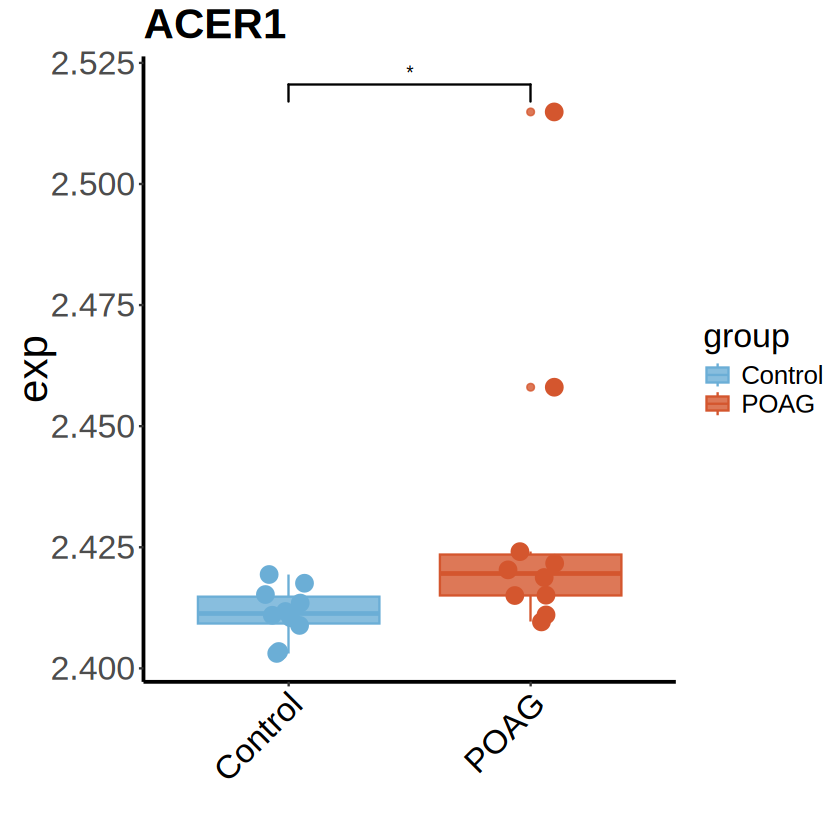

In [48]:
i="ACER1"
p1 <- ggplot(m,aes(x=group,y=m[[i]],fill=group))+geom_boxplot(size=0.5,alpha=0.8,aes(color=group)) +
scale_fill_manual(values = cols1) +scale_color_manual(values = cols1)+
labs(title=i,x="",y="")+
geom_signif(comparisons = list(c('Control','POAG')),map_signif_level = T,test = "wilcox.test",step_increase = 0.1)+
geom_jitter(data = m, aes(y = m[[i]]),
              size = 5, shape = 21,
              color="black",
              stroke = 0.01, show.legend = FALSE,
              position = position_jitterdodge())+
theme_classic ()+theme(axis.text = element_text (size = 20))+
    theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"),
         axis.text.x= element_text(color = 'black', size = 20, angle = 45,hjust = 1))+
    theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+
    theme(plot.title = element_text(size = 25, face = "bold"))+
    theme(axis.line = element_line(color = "black",linewidth = 0.8))+
    theme(legend.title = element_text(size=20),
          legend.text = element_text(size=15))+#+scale_y_continuous(limits = c(0,max(mer1[[i]])))
    labs(y="exp")
print(p1)

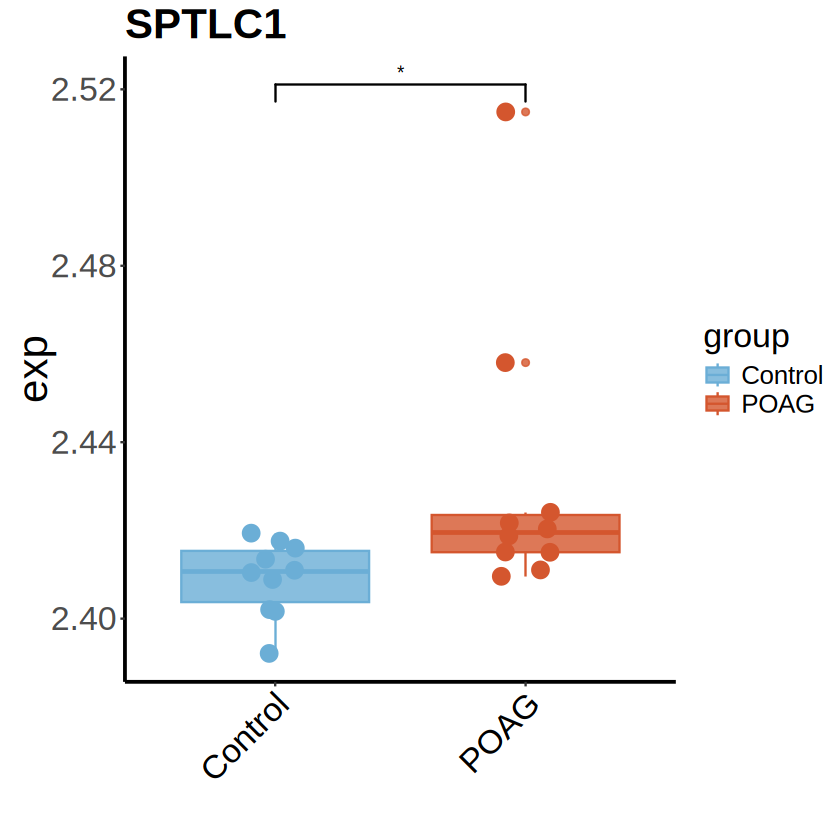

In [37]:
i="SPTLC1"
p1 <- ggplot(m,aes(x=group,y=m[[i]],fill=group))+geom_boxplot(size=0.5,alpha=0.8,aes(color=group)) +
scale_fill_manual(values = cols1) +scale_color_manual(values = cols1)+
labs(title=i,x="",y="")+
geom_signif(comparisons = list(c('Control','POAG')),map_signif_level = T,test = "wilcox.test",step_increase = 0.1)+
geom_jitter(data = m, aes(y = m[[i]]),
              size = 5, shape = 21,
              color="black",
              stroke = 0.01, show.legend = FALSE,
              position = position_jitterdodge())+
theme_classic ()+theme(axis.text = element_text (size = 20))+
    theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"),
         axis.text.x= element_text(color = 'black', size = 20, angle = 45,hjust = 1))+
    theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+
    theme(plot.title = element_text(size = 25, face = "bold"))+
    theme(axis.line = element_line(color = "black",linewidth = 0.8))+
    theme(legend.title = element_text(size=20),
          legend.text = element_text(size=15))+#+scale_y_continuous(limits = c(0,max(mer1[[i]])))
    labs(y="exp")
print(p1)

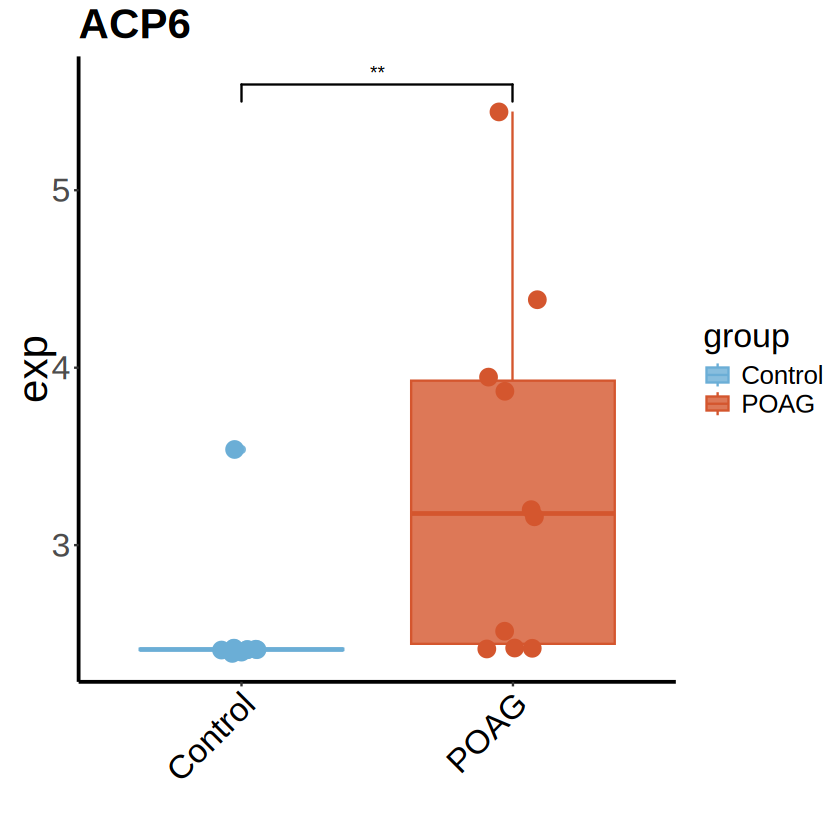

In [43]:
i="ACP6"
p1 <- ggplot(m,aes(x=group,y=m[[i]],fill=group))+geom_boxplot(size=0.5,alpha=0.8,aes(color=group)) +
scale_fill_manual(values = cols1) +scale_color_manual(values = cols1)+
labs(title=i,x="",y="")+
geom_signif(comparisons = list(c('Control','POAG')),map_signif_level = T,test = "wilcox.test",step_increase = 0.1)+
geom_jitter(data = m, aes(y = m[[i]]),
              size = 5, shape = 21,
              color="black",
              stroke = 0.01, show.legend = FALSE,
              position = position_jitterdodge())+
theme_classic ()+theme(axis.text = element_text (size = 20))+
    theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"),
         axis.text.x= element_text(color = 'black', size = 20, angle = 45,hjust = 1))+
    theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+
    theme(plot.title = element_text(size = 25, face = "bold"))+
    theme(axis.line = element_line(color = "black",linewidth = 0.8))+
    theme(legend.title = element_text(size=20),
          legend.text = element_text(size=15))+#+scale_y_continuous(limits = c(0,max(mer1[[i]])))
    labs(y="exp")
print(p1)

In [62]:
gs <- read.csv(paste0(path,"ggs_ud.csv"),row.names = 1)

In [63]:
head(gs)

,gs_name,gene_symbol
,<chr>,<chr>
180542,glycerophospholipid biosynthetic process,ABHD3
180543,glycerophospholipid biosynthetic process,ABHD4
180544,glycerophospholipid biosynthetic process,ABHD5
180545,glycerophospholipid biosynthetic process,ABHD8
180546,glycerophospholipid biosynthetic process,ACP6
180547,glycerophospholipid biosynthetic process,ACSL3


In [64]:
genesets <- split(gs$gene_symbol, gs$gs_name)#
head(genesets)

$`glycerophospholipid biosynthetic process`
  [1] "ABHD3"    "ABHD4"    "ABHD5"    "ABHD8"    "ACP6"     "ACSL3"   
  [7] "AGPAT1"   "AGPAT1"   "AGPAT1"   "AGPAT1"   "AGPAT1"   "AGPAT1"  
 [13] "AGPAT1"   "AGPAT2"   "AGPAT3"   "AGPAT4"   "AGPAT5"   "AGPAT5"  
 [19] "AJUBA"    "ALOX15"   "APOA1"    "APOA2"    "ATG14"    "ATM"     
 [25] "BECN1"    "BMX"      "BPNT1"    "BPNT2"    "CAPN2"    "CDIPT"   
 [31] "CDS1"     "CDS2"     "CEPT1"    "CHAT"     "CHKA"     "CHKB"    
 [37] "CHPT1"    "CISH"     "CLN3"     "CRLS1"    "CWH43"    "DGKA"    
 [43] "DGKB"     "DGKD"     "DGKD"     "DGKE"     "DGKG"     "DGKH"    
 [49] "DGKQ"     "DGKZ"     "DHRS7B"   "DPM1"     "DPM2"     "DPM3"    
 [55] "EFR3A"    "EFR3B"    "ETNK1"    "ETNK2"    "FABP3"    "FABP5"   
 [61] "FAM126A"  "FAM126B"  "FAR1"     "FGF2"     "FIG4"     "GNPAT"   
 [67] "GPAA1"    "GPAM"     "GPAT2"    "GPAT3"    "GPAT4"    "HDHD5"   
 [73] "HTR2A"    "HTR2B"    "HTR2C"    "IMPA1"    "IMPA2"    "INPP1"   
 [79] "INPP4A"   "INPP4B"   "INPP5D"   "INPP5D"   "INPP5E"   "INPP5F"  
 [85] "INPP5J"   "INPP5K"   "INPPL1"   "IP6K1"    "IP6K2"    "IP6K3"   
 [91] "IPMK"     "ITPKA"    "ITPKB"    "ITPKC"    "LCAT"     "LCLAT1"  
 [97] "LIPH"     "LIPI"     "LPCAT1"   "LPCAT1"   "LPCAT2"   "LPCAT3"  
[103] "LPCAT4"   "LPIN1"    "MBOAT7"   "MBOAT7"   "MBOAT7"   "MBOAT7"  
[109] "MBOAT7"   "MBOAT7"   "MBOAT7"   "MBOAT7"   "MBOAT7"   "MBOAT7"  
[115] "MFSD2A"   "MPPE1"    "MTM1"     "MTMR1"    "MTMR14"   "MTMR2"   
[121] "MTMR3"    "MTMR4"    "MTMR6"    "MTMR7"    "NR1H4"    "OCRL"    
[127] "P3R3URF"  "PCYT1A"   "PCYT1B"   "PCYT2"    "PDGFA"    "PDGFB"   
[133] "PEMT"     "PGAP1"    "PGAP2"    "PGAP3"    "PGAP4"    "PGS1"    
[139] "PI4K2A"   "PI4K2B"   "PI4KA"    "PI4KAP1"  "PI4KAP2"  "PI4KB"   
[145] "PIGA"     "PIGB"     "PIGC"     "PIGF"     "PIGG"     "PIGG"    
[151] "PIGH"     "PIGK"     "PIGL"     "PIGM"     "PIGN"     "PIGO"    
[157] "PIGP"     "PIGQ"     "PIGS"     "PIGT"     "PIGU"     "PIGV"    
[163] "PIGW"     "PIGW"     "PIGX"     "PIGY"     "PIGZ"     "PIK3C2A" 
[169] "PIK3C2B"  "PIK3C2G"  "PIK3C3"   "PIK3CA"   "PIK3CB"   "PIK3CD"  
[175] "PIK3CG"   "PIK3R1"   "PIK3R2"   "PIK3R3"   "PIK3R4"   "PIK3R6"  
[181] "PIKFYVE"  "PIP4K2A"  "PIP4K2B"  "PIP4K2B"  "PIP4K2C"  "PIP5K1A" 
[187] "PIP5K1B"  "PIP5K1C"  "PIP5KL1"  "PIPSL"    "PISD"     "PITPNM1" 
[193] "PITPNM2"  "PITPNM3"  "PLA2G4A"  "PLA2G4C"  "PLA2G6"   "PLCG2"   
[199] "PLD1"     "PLD2"     "PLSCR1"   "PLSCR3"   "PLSCR3"   "PNPLA3"  
[205] "PTDSS1"   "PTDSS2"   "PTDSS2"   "PTEN"     "PTEN"     "PTPMT1"  
[211] "PTPMT1"   "RAB38"    "SACM1L"   "SELENOI"  "SH3YL1"   "SLA2"    
[217] "SLC27A1"  "SLC44A1"  "SLC44A2"  "SLC44A3"  "SLC44A4"  "SLC44A4" 
[223] "SLC44A4"  "SLC44A4"  "SLC44A4"  "SLC44A4"  "SLC44A4"  "SLC44A4" 
[229] "SLC44A5"  "SMG1"     "SOCS1"    "SOCS2"    "SOCS3"    "SOCS4"   
[235] "SOCS5"    "SOCS6"    "SOCS7"    "SOCS7"    "SYNJ1"    "SYNJ2"   
[241] "TAFAZZIN" "TAMM41"   "TAMM41"   "TMEM150A" "TPTE2"    "TTC7A"   
[247] "TTC7B"    "UVRAG"    "VAC14"   

$`glycerophospholipid catabolic process`
 [1] "ABHD12"   "ABHD12B"  "ABHD16A"  "ABHD16A"  "ABHD16A"  "ABHD16A" 
 [7] "ABHD16A"  "ABHD16A"  "ABHD16A"  "ABHD16B"  "APOC1"    "ENPP2"   
[13] "ENPP6"    "GDE1"     "GDPD1"    "GDPD3"    "GPCPD1"   "INPP5F"  
[19] "LDLR"     "LIPC"     "PLA2G10"  "PLA2G10"  "PLA2G15"  "PLA2G4A" 
[25] "PLA2G4B"  "PLA2G4C"  "PLA2G4D"  "PLA2G4E"  "PLA2G4F"  "PLA2G5"  
[31] "PLA2G6"   "PLA2G7"   "PLB1"     "PLCB1"    "PNLIPRP2" "PNPLA6"  
[37] "PNPLA7"   "PNPLA8"   "PRDX6"    "SCARB1"   "SMPD4"   

$`glycerophospholipid metabolic process`
  [1] "ABCA3"    "ABHD12"   "ABHD12B"  "ABHD16A"  "ABHD16A"  "ABHD16A" 
  [7] "ABHD16A"  "ABHD16A"  "ABHD16A"  "ABHD16A"  "ABHD16B"  "ABHD3"   
 [13] "ABHD4"    "ABHD5"    "ABHD6"    "ABHD8"    "ACP6"     "ACSL3"   
 [19] "AGPAT1"   "AGPAT1"   "AGPAT1"   "AGPAT1"   "AGPAT1"   "AGPAT1"  
 [25] "AGPAT1"   "AGPAT2"   "AGPAT3"   "AGPAT4"   "AGPAT5"   "AGPAT5"  
 [31] "AJUBA"    "ALOX15"   "APOA1"

In [65]:
gsvapar <- gsvaParam(as.matrix(mer3), genesets)
gsva_es <- gsva(gsvapar)

ℹ GSVA version 2.0.4

ℹ Calculating GSVA ranks

ℹ kcdf='auto' (default)

ℹ GSVA dense (classical) algorithm

ℹ Row-wise ECDF estimation with Gaussian kernels

ℹ Calculating GSVA column ranks

! Duplicated gene IDs removed from gene set glycerophospholipid biosynthetic process

! Duplicated gene IDs removed from gene set glycerophospholipid catabolic process

! Duplicated gene IDs removed from gene set glycerophospholipid metabolic process

! Duplicated gene IDs removed from gene set sphingosine biosynthetic process

ℹ Calculating GSVA scores

✔ Calculations finished



In [66]:
ann_colors = list( group = c("Control"="#337AB7","POAG"="#F0AD4E"))
cols <- c("Control"="#337AB7","POAG"="#F0AD4E")

In [67]:
group <- data.frame(group=sp@meta.data$group)  # 分组信息
rownames(group)=colnames(mer3)

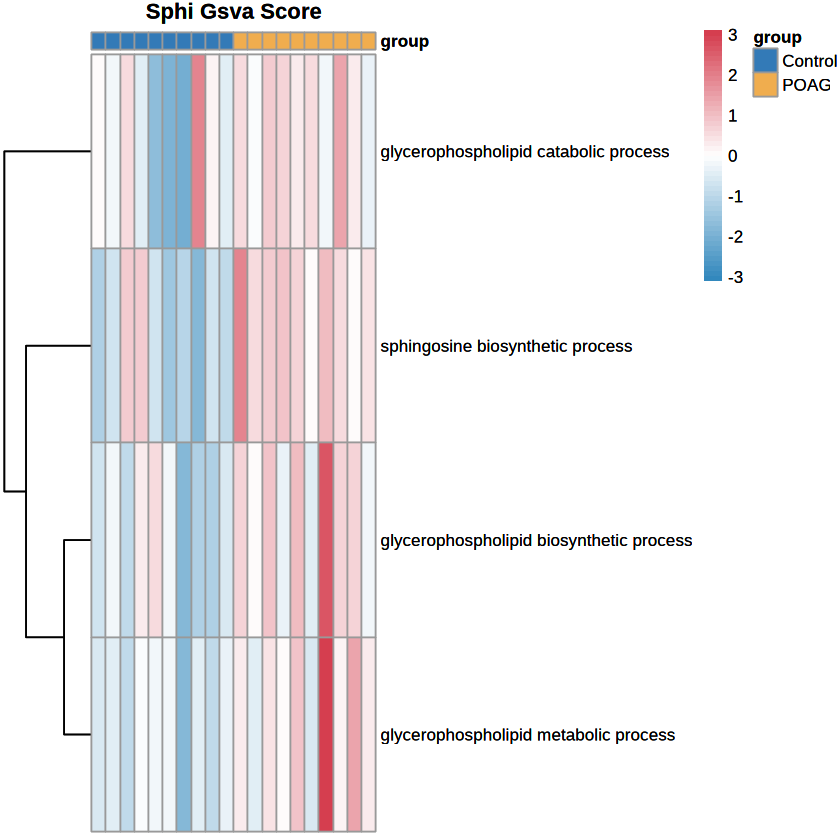

In [68]:
p <- pheatmap(gsva_es,    # 热图数据源，数值型矩阵，numeric
              scale = "row",          # 按行标准化
              show_colnames =FALSE,       # 是否显示列名
              show_rownames = T,      # 是否显示行名
              cluster_cols = FALSE,       # 是否按列聚类
              annotation_colors = ann_colors,
              color=colorRampPalette(c("#3288BD","white","#D53E4F"))(50),
              annotation_col=group,   # 构建列注释数据框
              main = "Sphi Gsva Score")   # 热图标题 
p 

In [71]:
mer <- merge(scale(t(gsva_es)),group,by=0,all=TRUE)
rownames(mer) <- mer$Row.names
mer <- mer[,-1]

In [72]:
head(genesets)

$`glycerophospholipid biosynthetic process`
  [1] "ABHD3"    "ABHD4"    "ABHD5"    "ABHD8"    "ACP6"     "ACSL3"   
  [7] "AGPAT1"   "AGPAT1"   "AGPAT1"   "AGPAT1"   "AGPAT1"   "AGPAT1"  
 [13] "AGPAT1"   "AGPAT2"   "AGPAT3"   "AGPAT4"   "AGPAT5"   "AGPAT5"  
 [19] "AJUBA"    "ALOX15"   "APOA1"    "APOA2"    "ATG14"    "ATM"     
 [25] "BECN1"    "BMX"      "BPNT1"    "BPNT2"    "CAPN2"    "CDIPT"   
 [31] "CDS1"     "CDS2"     "CEPT1"    "CHAT"     "CHKA"     "CHKB"    
 [37] "CHPT1"    "CISH"     "CLN3"     "CRLS1"    "CWH43"    "DGKA"    
 [43] "DGKB"     "DGKD"     "DGKD"     "DGKE"     "DGKG"     "DGKH"    
 [49] "DGKQ"     "DGKZ"     "DHRS7B"   "DPM1"     "DPM2"     "DPM3"    
 [55] "EFR3A"    "EFR3B"    "ETNK1"    "ETNK2"    "FABP3"    "FABP5"   
 [61] "FAM126A"  "FAM126B"  "FAR1"     "FGF2"     "FIG4"     "GNPAT"   
 [67] "GPAA1"    "GPAM"     "GPAT2"    "GPAT3"    "GPAT4"    "HDHD5"   
 [73] "HTR2A"    "HTR2B"    "HTR2C"    "IMPA1"    "IMPA2"    "INPP1"   
 [79] "INPP4A"   "INPP4B"   "INPP5D"   "INPP5D"   "INPP5E"   "INPP5F"  
 [85] "INPP5J"   "INPP5K"   "INPPL1"   "IP6K1"    "IP6K2"    "IP6K3"   
 [91] "IPMK"     "ITPKA"    "ITPKB"    "ITPKC"    "LCAT"     "LCLAT1"  
 [97] "LIPH"     "LIPI"     "LPCAT1"   "LPCAT1"   "LPCAT2"   "LPCAT3"  
[103] "LPCAT4"   "LPIN1"    "MBOAT7"   "MBOAT7"   "MBOAT7"   "MBOAT7"  
[109] "MBOAT7"   "MBOAT7"   "MBOAT7"   "MBOAT7"   "MBOAT7"   "MBOAT7"  
[115] "MFSD2A"   "MPPE1"    "MTM1"     "MTMR1"    "MTMR14"   "MTMR2"   
[121] "MTMR3"    "MTMR4"    "MTMR6"    "MTMR7"    "NR1H4"    "OCRL"    
[127] "P3R3URF"  "PCYT1A"   "PCYT1B"   "PCYT2"    "PDGFA"    "PDGFB"   
[133] "PEMT"     "PGAP1"    "PGAP2"    "PGAP3"    "PGAP4"    "PGS1"    
[139] "PI4K2A"   "PI4K2B"   "PI4KA"    "PI4KAP1"  "PI4KAP2"  "PI4KB"   
[145] "PIGA"     "PIGB"     "PIGC"     "PIGF"     "PIGG"     "PIGG"    
[151] "PIGH"     "PIGK"     "PIGL"     "PIGM"     "PIGN"     "PIGO"    
[157] "PIGP"     "PIGQ"     "PIGS"     "PIGT"     "PIGU"     "PIGV"    
[163] "PIGW"     "PIGW"     "PIGX"     "PIGY"     "PIGZ"     "PIK3C2A" 
[169] "PIK3C2B"  "PIK3C2G"  "PIK3C3"   "PIK3CA"   "PIK3CB"   "PIK3CD"  
[175] "PIK3CG"   "PIK3R1"   "PIK3R2"   "PIK3R3"   "PIK3R4"   "PIK3R6"  
[181] "PIKFYVE"  "PIP4K2A"  "PIP4K2B"  "PIP4K2B"  "PIP4K2C"  "PIP5K1A" 
[187] "PIP5K1B"  "PIP5K1C"  "PIP5KL1"  "PIPSL"    "PISD"     "PITPNM1" 
[193] "PITPNM2"  "PITPNM3"  "PLA2G4A"  "PLA2G4C"  "PLA2G6"   "PLCG2"   
[199] "PLD1"     "PLD2"     "PLSCR1"   "PLSCR3"   "PLSCR3"   "PNPLA3"  
[205] "PTDSS1"   "PTDSS2"   "PTDSS2"   "PTEN"     "PTEN"     "PTPMT1"  
[211] "PTPMT1"   "RAB38"    "SACM1L"   "SELENOI"  "SH3YL1"   "SLA2"    
[217] "SLC27A1"  "SLC44A1"  "SLC44A2"  "SLC44A3"  "SLC44A4"  "SLC44A4" 
[223] "SLC44A4"  "SLC44A4"  "SLC44A4"  "SLC44A4"  "SLC44A4"  "SLC44A4" 
[229] "SLC44A5"  "SMG1"     "SOCS1"    "SOCS2"    "SOCS3"    "SOCS4"   
[235] "SOCS5"    "SOCS6"    "SOCS7"    "SOCS7"    "SYNJ1"    "SYNJ2"   
[241] "TAFAZZIN" "TAMM41"   "TAMM41"   "TMEM150A" "TPTE2"    "TTC7A"   
[247] "TTC7B"    "UVRAG"    "VAC14"   

$`glycerophospholipid catabolic process`
 [1] "ABHD12"   "ABHD12B"  "ABHD16A"  "ABHD16A"  "ABHD16A"  "ABHD16A" 
 [7] "ABHD16A"  "ABHD16A"  "ABHD16A"  "ABHD16B"  "APOC1"    "ENPP2"   
[13] "ENPP6"    "GDE1"     "GDPD1"    "GDPD3"    "GPCPD1"   "INPP5F"  
[19] "LDLR"     "LIPC"     "PLA2G10"  "PLA2G10"  "PLA2G15"  "PLA2G4A" 
[25] "PLA2G4B"  "PLA2G4C"  "PLA2G4D"  "PLA2G4E"  "PLA2G4F"  "PLA2G5"  
[31] "PLA2G6"   "PLA2G7"   "PLB1"     "PLCB1"    "PNLIPRP2" "PNPLA6"  
[37] "PNPLA7"   "PNPLA8"   "PRDX6"    "SCARB1"   "SMPD4"   

$`glycerophospholipid metabolic process`
  [1] "ABCA3"    "ABHD12"   "ABHD12B"  "ABHD16A"  "ABHD16A"  "ABHD16A" 
  [7] "ABHD16A"  "ABHD16A"  "ABHD16A"  "ABHD16A"  "ABHD16B"  "ABHD3"   
 [13] "ABHD4"    "ABHD5"    "ABHD6"    "ABHD8"    "ACP6"     "ACSL3"   
 [19] "AGPAT1"   "AGPAT1"   "AGPAT1"   "AGPAT1"   "AGPAT1"   "AGPAT1"  
 [25] "AGPAT1"   "AGPAT2"   "AGPAT3"   "AGPAT4"   "AGPAT5"   "AGPAT5"  
 [31] "AJUBA"    "ALOX15"   "APOA1"

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


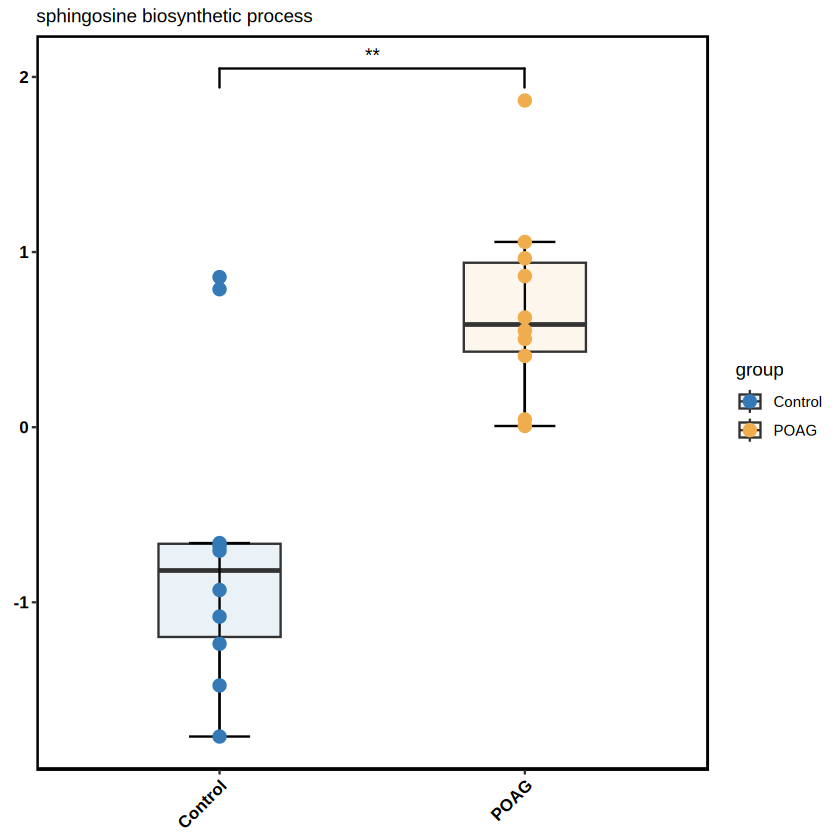

In [75]:
i="sphingosine biosynthetic process"
p <- ggplot(mer,aes(x=group,y=mer[[i]],fill=group))+geom_boxplot(position=position_dodge(width=0.2), width=0.4,alpha=0.1) +
stat_boxplot(geom="errorbar", position=position_dodge(width=0.4), width=0.2)+geom_point(aes(fill=group, group=group, color=group), pch=21, size=3,position=position_dodge(0.4)) +
geom_signif(comparisons = list(c('Control','POAG')),map_signif_level = T,test = "wilcox.test",step_increase = 0.05)+
scale_fill_simpsons(alpha=0.7)+scale_color_simpsons(alpha=0.7)+
labs(x=NULL, y=NULL,subtitle = i)+
theme(
    panel.border = element_rect(
      color = "black",
      fill = NA,
      linewidth = 1
    ),panel.background = element_rect(fill = "white")
  )+
theme(axis.text.y=element_text(color="black", size=10, face="bold"), # 自定义y轴上的文本
axis.text.x=element_text(color="black", size=10, hjust=1, face="bold", angle=45) # 自定义x轴上的文本
     )+scale_fill_manual(values = cols) +scale_color_manual(values = cols)
print(p)
ggsave(paste0(i,"_gsva_bulk.pdf"),p,width = 4,height = 4.5)

In [57]:
setwd(path)

In [58]:
pdf("human_sphing_gsva_bulkrna.pdf",width = 4,height = 4.5)
for(i in rownames(gsva_es)){
    p <- ggplot(mer,aes(x=group,y=mer[[i]],fill=group))+geom_boxplot(position=position_dodge(width=0.2), width=0.4,alpha=0.1) +
stat_boxplot(geom="errorbar", position=position_dodge(width=0.4), width=0.2)+geom_point(aes(fill=group, group=group, color=group), pch=21, size=3,position=position_dodge(0.4)) +
geom_signif(comparisons = list(c('Control','POAG')),map_signif_level = T,test = "wilcox.test",step_increase = 0.05)+
scale_fill_simpsons(alpha=0.7)+scale_color_simpsons(alpha=0.7)+
labs(x=NULL, y=NULL,subtitle = i)+
theme(
    panel.border = element_rect(
      color = "black",
      fill = NA,
      linewidth = 1
    ),panel.background = element_rect(fill = "white")
  )+
theme(axis.text.y=element_text(color="black", size=10, face="bold"), # 自定义y轴上的文本
axis.text.x=element_text(color="black", size=10, hjust=1, face="bold", angle=45) # 自定义x轴上的文本
     )+scale_fill_manual(values = col) +scale_color_manual(values = col)
print(p)
}
dev.off()

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Ad

pdf 
  2

In [59]:
pdf("./human_sphing_gsva_bulkrna_raw.pdf",width = 4,height = 4.5)
for(i in rownames(gsva_es)){
    p <- ggplot(mer,aes(x=group,y=mer[[i]],fill=group))+geom_boxplot(position=position_dodge(width=0.2), width=0.4,alpha=0.1) +
stat_boxplot(geom="errorbar", position=position_dodge(width=0.4), width=0.2)+geom_point(aes(fill=group, group=group, color=group), pch=21, size=3,position=position_dodge(0.4)) +
geom_signif(comparisons = list(c('Control','POAG')),map_signif_level = T,test = "wilcox.test",step_increase = 0.05)+
scale_fill_simpsons(alpha=0.7)+scale_color_simpsons(alpha=0.7)+
labs(x=NULL, y=NULL,subtitle = i)+
theme(
    panel.border = element_rect(
      color = "black",
      fill = NA,
      linewidth = 1
    ),panel.background = element_rect(fill = "white")
  )+
theme(axis.text.y=element_text(color="black", size=10, face="bold"), # 自定义y轴上的文本
axis.text.x=element_text(color="black", size=10, hjust=1, face="bold", angle=45) # 自定义x轴上的文本
     )+scale_fill_manual(values = col) +scale_color_manual(values = col)
print(p)
}
dev.off()

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Ad

pdf 
  2